# Notebook 1 — Load & Verify Labeled Dataset

**Input:** `combined_labeled.csv` (already label-fixed from Notebook 0)

**Output:** Verified DataFrame ready for feature selection

---

## What this notebook does
| Step | Action |
|---|---|
| 1 | Load `combined_labeled.csv` |
| 2 | Verify shape, dtypes, label distribution |
| 3 | Plot class distribution bar chart |
| 4 | Save verified df to memory for next notebook |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = r'D:\Computer Engineering 2022\4-CE.Z Forth Year\second-semester-4.2\project\ML-NIDS-Android\03-dataset\02-processed\02_combined_labeled.csv'

print('Loading...')
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f'Shape : {df.shape}')
print(f'Columns: {df.shape[1]}')
print(f'Rows   : {df.shape[0]:,}')

Loading...
Shape : (2827829, 85)
Columns: 85
Rows   : 2,827,829


In [2]:
# Label distribution
LABEL_NAMES = {0:'BENIGN', 1:'DoS', 2:'DDoS', 3:'PortScan', 4:'BruteForce', 5:'WebAttack', 6:'Bot'}

counts = df['Label'].value_counts().sort_index()
print('Label distribution:')
for code, count in counts.items():
    name = LABEL_NAMES.get(int(code), str(code))
    pct  = count / len(df) * 100
    print(f'  {int(code)} — {name:<12}: {count:>10,}  ({pct:.2f}%)')

Label distribution:
  0 — BENIGN      :  2,271,320  (80.32%)
  1 — DoS         :    251,712  (8.90%)
  2 — DDoS        :    128,025  (4.53%)
  3 — PortScan    :    158,804  (5.62%)
  4 — BruteForce  :     13,832  (0.49%)
  5 — WebAttack   :      2,180  (0.08%)
  6 — Bot         :      1,956  (0.07%)


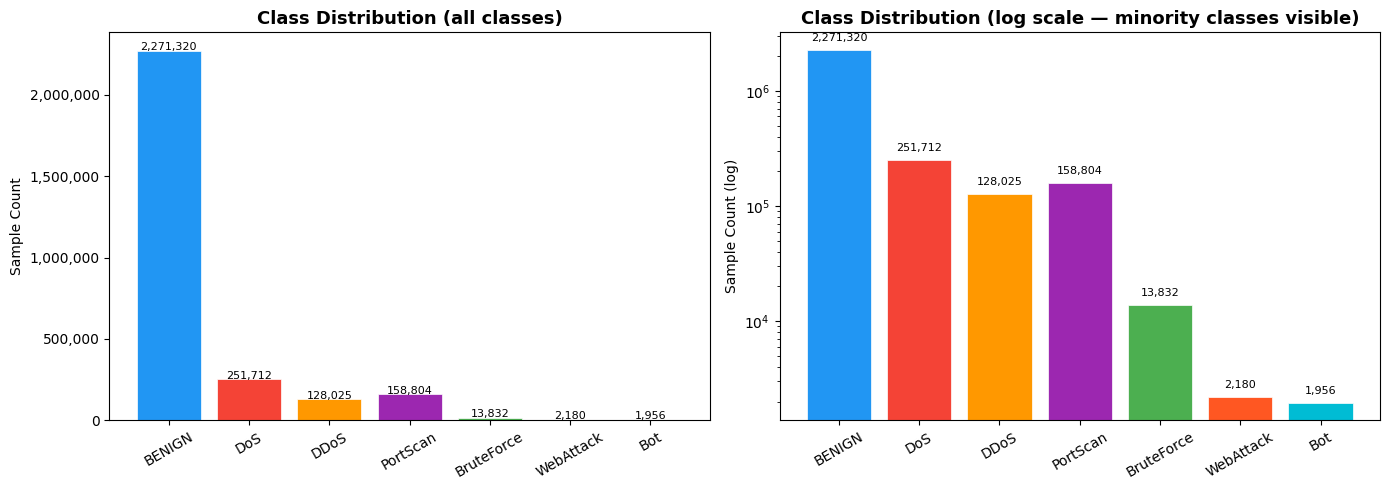

Saved 01_class_distribution.png


In [3]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [LABEL_NAMES[int(c)] for c in counts.index]
colors = ['#2196F3','#F44336','#FF9800','#9C27B0','#4CAF50','#FF5722','#00BCD4']

# Bar chart — all classes
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution (all classes)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=8)

# Log scale — to see minority classes
axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (log scale — minority classes visible)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sample Count (log)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[1].text(i, v * 1.2, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150)
plt.show()
print('Saved 01_class_distribution.png')

In [4]:
# Quick dtype check
print('Numeric columns  :', df.select_dtypes(include=np.number).shape[1])
print('Non-numeric cols :', df.select_dtypes(exclude=np.number).shape[1])
print('NaN values       :', df.isnull().sum().sum())
print('\nAll good — ready for Notebook 2 (Feature Selection)')

Numeric columns  : 81
Non-numeric cols : 4
NaN values       : 0

All good — ready for Notebook 2 (Feature Selection)
